EDA - wczytanie danych i analiza

In [2]:
import pandas as pd
import numpy as np

df = pd.read_json('../backend/data/raw/fast_cars_data.json')

df.info()
df.describe()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 15968 entries, 0 to 15967
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Tytuł              15968 non-null  str  
 1   Cena               15968 non-null  str  
 2   URL                15968 non-null  str  
 3   Rok produkcji      15968 non-null  int64
 4   Przebieg           15968 non-null  str  
 5   Pojemność skokowa  15968 non-null  str  
 6   Moc                15968 non-null  str  
 7   Rodzaj paliwa      15968 non-null  str  
 8   Skrzynia biegów    15968 non-null  str  
dtypes: int64(1), str(8)
memory usage: 1.1 MB


,Tytuł,Cena,URL,Rok produkcji,Przebieg,Pojemność skokowa,Moc,Rodzaj paliwa,Skrzynia biegów
0,Citroën C5 Aircross 1.6 PHEV 225 Shine Pack EAT8,85200 PLN,https://www.otomoto.pl/osobowe/oferta/citroen-...,2022,104705 km,1598 cm3,225 KM,Hybryda Plug-in,Automatyczna
1,Omoda 9 1.5 Super Hybrid Exclusive AWD,224900 PLN,https://www.otomoto.pl/osobowe/oferta/omoda-9-...,2026,10 km,1499 cm3,537 KM,Hybryda Plug-in,Automatyczna
2,Seat Leon 1.5 e-Hybrid DSG FR,69900 PLN,https://www.otomoto.pl/osobowe/oferta/seat-leo...,2021,59999 km,1498 cm3,204 KM,Hybryda Plug-in,Automatyczna
3,Honda Civic 1.5 T Prestige (Navi),67000 PLN,https://www.otomoto.pl/osobowe/oferta/honda-ci...,2020,104000 km,1498 cm3,182 KM,Benzyna,Automatyczna
4,Peugeot 508,24900 PLN,https://www.otomoto.pl/osobowe/oferta/peugeot-...,2013,141000 km,1997 cm3,200 KM,Hybryda,Automatyczna


In [3]:
df = df.replace('Brak', np.nan)

braki = df[['Rok produkcji', 'Cena', 'Przebieg', 'Pojemność skokowa', 'Moc', 'Rodzaj paliwa', 'Skrzynia biegów']].isna().sum()
print(braki)

def test(df):
    warunek_brak_pojemnosci = df['Pojemność skokowa'].isna()
    warunek_elektryk = df['Rodzaj paliwa'] == 'Elektryczny'
    warunek_moc = df['Moc'].isna()

    unikalne_paliwa = df['Rodzaj paliwa'].unique()

    print("Dostępne rodzaje paliwa w bazie:")
    print(unikalne_paliwa)

    for typ_paliwa in unikalne_paliwa:
        warunek_paliwo = df['Rodzaj paliwa'] == typ_paliwa
        print(f"Liczba aut o paliwie \"{typ_paliwa}\": {warunek_paliwo.sum()}")
        print(f"Ilość wpisów z brakującą pojemnością skokową dla tego paliwa \"{typ_paliwa}\": {(warunek_paliwo & warunek_brak_pojemnosci).sum()}")
        print(f"Ilość wpisów z brakującą mocą dla tego paliwa \"{typ_paliwa}\": {(warunek_paliwo & warunek_moc).sum()}")
        
test(df)
df = df.drop_duplicates()
test(df)


Rok produkcji          0
Cena                   0
Przebieg               0
Pojemność skokowa    333
Moc                  188
Rodzaj paliwa          0
Skrzynia biegów        2
dtype: int64
Dostępne rodzaje paliwa w bazie:
<StringArray>
['Hybryda Plug-in',         'Benzyna',         'Hybryda',          'Diesel',
     'Benzyna+LPG',     'Elektryczny',     'Benzyna+CNG',           'Wodór']
Length: 8, dtype: str
Liczba aut o paliwie "Hybryda Plug-in": 422
Ilość wpisów z brakującą pojemnością skokową dla tego paliwa "Hybryda Plug-in": 4
Ilość wpisów z brakującą mocą dla tego paliwa "Hybryda Plug-in": 4
Liczba aut o paliwie "Benzyna": 8085
Ilość wpisów z brakującą pojemnością skokową dla tego paliwa "Benzyna": 27
Ilość wpisów z brakującą mocą dla tego paliwa "Benzyna": 91
Liczba aut o paliwie "Hybryda": 845
Ilość wpisów z brakującą pojemnością skokową dla tego paliwa "Hybryda": 6
Ilość wpisów z brakującą mocą dla tego paliwa "Hybryda": 6
Liczba aut o paliwie "Diesel": 5766
Ilość wpisów z brak

Czyszczenie danych i zamiana tekstu na liczby

In [4]:
print(f"Rozmiar bazy na start: {len(df)}")

df = df[~df['Rodzaj paliwa'].isin(['Benzyna+CNG', 'Wodór'])]

df.loc[df['Rodzaj paliwa'] == 'Elektryczny', 'Pojemność skokowa'] = '0'

df = df.dropna(subset=['Moc', 'Pojemność skokowa', 'Skrzynia biegów'])

print(f"Rozmiar bazy po usunięciu braków i mikrogrup: {len(df)}")


df['Cena'] = df['Cena'].astype(str)
df = df[df['Cena'].str.contains('PLN', na=False)]
df['Cena'] = df['Cena'].str.replace(' PLN', '', regex=False)
df['Cena'] = df['Cena'].str.replace(' ', '', regex=False)
df['Cena'] = df['Cena'].astype(float).astype(int)

df['Przebieg'] = df['Przebieg'].astype(str).str.replace(' km', '', regex=False)
df['Przebieg'] = df['Przebieg'].str.replace(' ', '', regex=False)
df['Przebieg'] = df['Przebieg'].astype(int)

df['Moc'] = df['Moc'].astype(str).str.replace(' KM', '', regex=False)
df['Moc'] = df['Moc'].str.replace(' ', '', regex=False)
df['Moc'] = df['Moc'].astype(int)

df['Pojemność skokowa'] = df['Pojemność skokowa'].astype(str).str.replace(' cm3', '', regex=False)
df['Pojemność skokowa'] = df['Pojemność skokowa'].str.replace(' ', '', regex=False)
# Tu używamy float a potem int, żeby ładnie przekonwertować zera
df['Pojemność skokowa'] = df['Pojemność skokowa'].astype(float).astype(int) 

print("\nSukces! Twoje dane są teraz czystymi liczbami.")

Rozmiar bazy na start: 15832
Rozmiar bazy po usunięciu braków i mikrogrup: 15594

Sukces! Twoje dane są teraz czystymi liczbami.


In [5]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
Index: 15579 entries, 0 to 15967
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Tytuł              15579 non-null  str  
 1   Cena               15579 non-null  int64
 2   URL                15579 non-null  str  
 3   Rok produkcji      15579 non-null  int64
 4   Przebieg           15579 non-null  int64
 5   Pojemność skokowa  15579 non-null  int64
 6   Moc                15579 non-null  int64
 7   Rodzaj paliwa      15579 non-null  str  
 8   Skrzynia biegów    15579 non-null  str  
dtypes: int64(5), str(4)
memory usage: 1.2 MB


,Cena,Rok produkcji,Przebieg,Pojemność skokowa,Moc
count,1.557900e+04,15579.000000,1.557900e+04,15579.000000,15579.000000
mean,8.320916e+04,2016.418512,1.407793e+05,1851.905000,171.860710
std,1.246267e+05,7.131441,1.047013e+05,773.464318,94.936135
min,9.000000e+02,1954.000000,1.000000e+00,0.000000,2.000000
25%,2.250000e+04,2011.000000,5.403350e+04,1482.000000,116.000000
50%,4.980000e+04,2017.000000,1.390000e+05,1793.000000,150.000000
75%,1.029000e+05,2022.000000,2.080000e+05,1995.000000,195.000000
max,4.698600e+06,2026.000000,2.188002e+06,9000.000000,2000.000000


Sprawdzanie wartości odstających i usuwanie ich

In [6]:
Q1 = df['Cena'].quantile(0.25)
Q3 = df['Cena'].quantile(0.75)

IQR = Q3 - Q1

df_outliers = df[(df['Cena'] < Q1 - 1.5 * IQR) | (df['Cena'] > Q3 + 1.5 * IQR)]

df_outliers

,Tytuł,Cena,URL,Rok produkcji,Przebieg,Pojemność skokowa,Moc,Rodzaj paliwa,Skrzynia biegów
1,Omoda 9 1.5 Super Hybrid Exclusive AWD,224900,https://www.otomoto.pl/osobowe/oferta/omoda-9-...,2026,10,1499,537,Hybryda Plug-in,Automatyczna
16,Lexus RX 500h F Sport,359960,https://www.otomoto.pl/osobowe/oferta/lexus-rx...,2024,16000,2393,370,Hybryda,Automatyczna
21,Porsche Cayenne E-Hybrid,320000,https://www.otomoto.pl/osobowe/oferta/porsche-...,2021,69000,2995,462,Hybryda Plug-in,Automatyczna
28,Mercedes-Benz AMG GT 43 4-Matic+,455000,https://www.otomoto.pl/osobowe/oferta/mercedes...,2022,30500,2999,367,Benzyna,Automatyczna
49,BMW X5 M M50i,249800,https://www.otomoto.pl/osobowe/oferta/bmw-x5-m...,2023,149800,4395,530,Benzyna,Automatyczna
...,...,...,...,...,...,...,...,...,...
15898,Audi SQ8,389900,https://www.otomoto.pl/osobowe/oferta/audi-sq8...,2023,72000,3996,507,Benzyna,Automatyczna
15921,Audi A6 Limousine,266402,https://www.otomoto.pl/osobowe/oferta/audi-a6-...,2026,10,1968,204,Diesel,Automatyczna
15927,Land Rover Defender,349000,https://www.otomoto.pl/osobowe/oferta/land-rov...,2026,5459,2998,200,Diesel,Automatyczna
15932,Porsche 911 Carrera S,539800,https://www.otomoto.pl/osobowe/oferta/porsche-...,2019,73681,2981,450,Benzyna,Automatyczna


To powyżej jest niepoprawnym sposobem w tym przypadku na identyfikowanie outlierów, bo nie jest to rozkład normalny, a z asymetrią prawostronną.

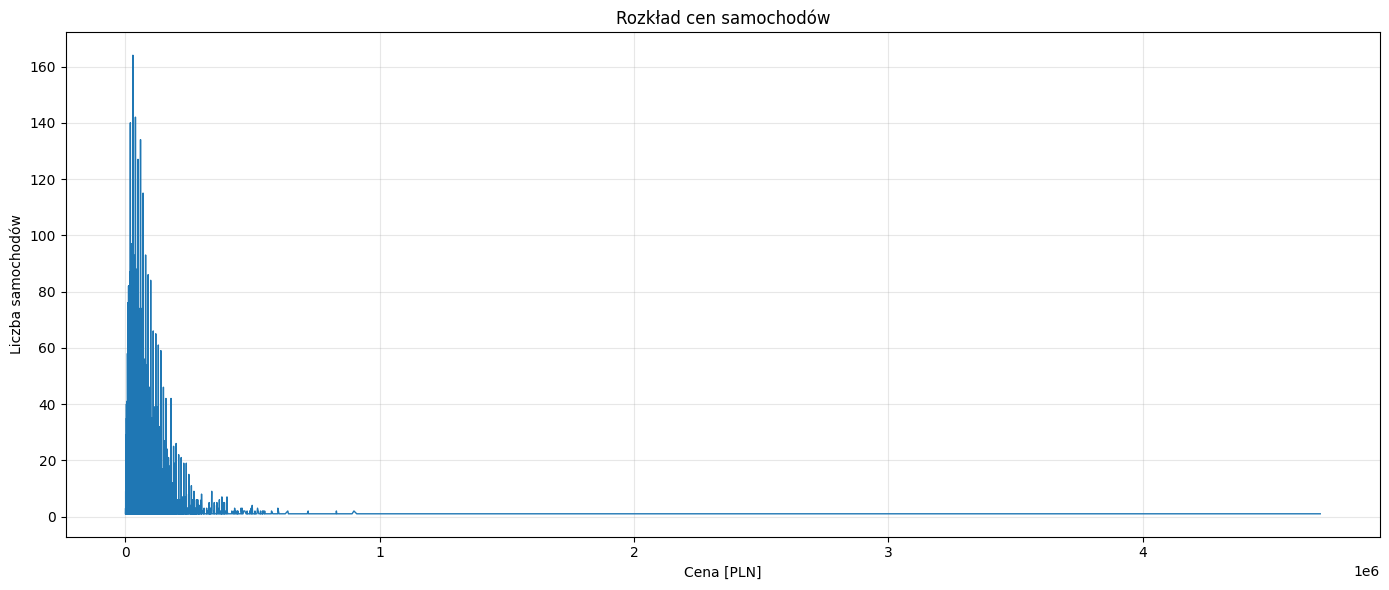

In [7]:
import matplotlib.pyplot as plt

price_counts = df["Cena"].value_counts().sort_index()

plt.figure(figsize=(14, 6))
plt.plot(price_counts.index, price_counts.values, linewidth=1)
plt.xlabel("Cena [PLN]")
plt.ylabel("Liczba samochodów")
plt.title("Rozkład cen samochodów")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Zatem zastosowane zostanie usuwanie logiczne, domenowe.

In [8]:
start_len = len(df)

df = df[(df['Cena'] >= 2500) & (df['Cena'] <= 800000)]

df = df[(df['Przebieg'] < 700000)]

warunek_pojemnosci = (df['Pojemność skokowa'] == 0) | ((df['Pojemność skokowa'] >= 600) & (df['Pojemność skokowa'] <= 8500))
df = df[warunek_pojemnosci]

df = df[df['Rok produkcji'] >= 1990]

print(f"Baza przed filtrowaniem: {start_len}")
print(f"Baza po filtrowaniu: {len(df)}")
print(f"Usunięto {start_len - len(df)} ekstremalnych przypadków (outlierów).")

Baza przed filtrowaniem: 15579
Baza po filtrowaniu: 15394
Usunięto 185 ekstremalnych przypadków (outlierów).


Feature engineering - zamiana rocznika na wiek samochodu

In [9]:
import datetime
df['Wiek'] = datetime.date.today().year - df['Rok produkcji']
df['Marka'] = df['Tytuł'].str.split(' ').str[0]

df = df.drop(columns=['Rok produkcji', 'Tytuł', 'URL'])

czestotliwosc_marek = df['Marka'].value_counts()
popularne_marki = czestotliwosc_marek[czestotliwosc_marek >= 30].index
df.loc[~df['Marka'].isin(popularne_marki), 'Marka'] = 'Inne'

df

,Cena,Przebieg,Pojemność skokowa,Moc,Rodzaj paliwa,Skrzynia biegów,Wiek,Marka
0,85200,104705,1598,225,Hybryda Plug-in,Automatyczna,4,Citroën
1,224900,10,1499,537,Hybryda Plug-in,Automatyczna,0,Inne
2,69900,59999,1498,204,Hybryda Plug-in,Automatyczna,5,Seat
3,67000,104000,1498,182,Benzyna,Automatyczna,6,Honda
4,24900,141000,1997,200,Hybryda,Automatyczna,13,Peugeot
...,...,...,...,...,...,...,...,...
15963,123900,5,1200,110,Hybryda,Automatyczna,0,Jeep
15964,139900,7,1200,145,Hybryda,Automatyczna,0,Jeep
15965,154900,7,1200,145,Hybryda,Automatyczna,0,Jeep
15966,49999,191814,1499,130,Diesel,Automatyczna,6,Peugeot


Encoding/One-Hot Encoding - tworzenie dummies, typu czy_elekryk: 0, czy_diesel: 1

In [10]:
df_ml = pd.get_dummies(df, columns=['Rodzaj paliwa', 'Skrzynia biegów', 'Marka'], drop_first=True, dtype=int)

Zapisanie datasetu

In [11]:
df_ml.to_csv("../backend/data/clean/dane_gotowe_ML.csv", index=False)
print(f"Zapisano zbiór")
df_ml

Zapisano zbiór


,Cena,Przebieg,Pojemność skokowa,Moc,Wiek,Rodzaj paliwa_Benzyna+LPG,Rodzaj paliwa_Diesel,Rodzaj paliwa_Elektryczny,Rodzaj paliwa_Hybryda,Rodzaj paliwa_Hybryda Plug-in,...,Marka_Peugeot,Marka_Porsche,Marka_Renault,Marka_Seat,Marka_Skoda,Marka_Subaru,Marka_Suzuki,Marka_Toyota,Marka_Volkswagen,Marka_Volvo
0,85200,104705,1598,225,4,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,224900,10,1499,537,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,69900,59999,1498,204,5,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
3,67000,104000,1498,182,6,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,24900,141000,1997,200,13,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15963,123900,5,1200,110,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
15964,139900,7,1200,145,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
15965,154900,7,1200,145,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
15966,49999,191814,1499,130,6,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
